In [11]:
import pandas as pd

print('ready')

ready


In [12]:
import numpy as np
import pandas as pd

np.random.seed(42)

dates = pd.date_range("2022-01-01", "2025-12-31", freq="D")
t = np.arange(len(dates))

trend = 500 + 0.15 * t + 0.00004 * t**2
yearly = 120 * np.sin(2 * np.pi * (dates.dayofyear - 80) / 365)
weekly = np.where(dates.dayofweek >= 5, 60, 0)
noise = np.random.normal(0, 45, len(dates))

sales = np.maximum(trend + yearly + weekly + noise, 0)

df = pd.DataFrame({
    "date": dates,
    "units_sold": sales.round().astype(int)
})

df.to_csv("historical_sales.csv", index=False)

print(df.shape)

(1461, 2)


In [13]:
import numpy as np

np.random.seed(1)

n = len(df)

# Make 25 random values missing
missing_idx = np.random.choice(n, size=25, replace=False)
df.loc[missing_idx, "units_sold"] = np.nan

# Make 8 random values extreme outliers
outlier_idx = np.random.choice(n, size=8, replace=False)
df.loc[outlier_idx, "units_sold"] = df.loc[outlier_idx, "units_sold"] * 6

# Duplicate 10 random rows
dup_rows = df.sample(10, random_state=1)
df = pd.concat([df, dup_rows], ignore_index=True).sort_values("date").reset_index(drop=True)

df.to_csv("historical_sales.csv", index=False)

print("New shape:", df.shape)
print("Missing values:", df["units_sold"].isna().sum())

New shape: (1471, 2)
Missing values: 35


In [14]:
df = pd.read_csv("historical_sales.csv", parse_dates=["date"])

print("Shape:", df.shape)

df.head()

Shape: (1471, 2)


,date,units_sold
0,2022-01-01,465.0
1,2022-01-02,437.0
2,2022-01-03,413.0
3,2022-01-04,453.0
4,2022-01-05,375.0


In [15]:
df.info()

df.isna().sum()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1471 entries, 0 to 1470
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1471 non-null   datetime64[us]
 1   units_sold  1436 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 23.1 KB


,date,units_sold
count,1471,1436.000000
mean,2023-12-31 22:11:20.353501,675.303621
min,2022-01-01 00:00:00,307.000000
25%,2022-12-31 12:00:00,564.000000
50%,2024-01-01 00:00:00,660.000000
75%,2024-12-29 12:00:00,752.250000
max,2025-12-31 00:00:00,4968.000000
std,NaN,277.737501


In [16]:
before = len(df)

df = df.drop_duplicates()

print(f"Removed {before - len(df)} duplicate rows")

Removed 10 duplicate rows


In [17]:
df = df.sort_values("date").set_index("date").asfreq("D")

print(df.shape)

(1461, 1)


In [18]:
df["units_sold"].interpolate(method="linear")

print("Missing after interpolation:", df["units_sold"].isna().sum())

Missing after interpolation: 25


In [20]:
df["units_sold"] = df["units_sold"].interpolate(method="linear")

print("Missing after interpolation:", df["units_sold"].isna().sum())

Missing after interpolation: 0


In [21]:
rolling_med = df["units_sold"].rolling(30, center=True, min_periods=5).median()

resid = df["units_sold"] - rolling_med

is_outlier = resid.abs() > 3 * resid.std()

print("Outliers found:", is_outlier.sum())

df.loc[is_outlier, "units_sold"] = rolling_med[is_outlier]

print("Outliers found:", is_outlier.sum())

Outliers found: 8
Outliers found: 8


In [22]:
print("Missing values:", df["units_sold"].isna().sum())

print(df["units_sold"].describe())

Missing values: 0
count    1461.000000
mean      657.110883
std       131.505244
min       307.000000
25%       563.000000
50%       659.000000
75%       749.000000
max      1023.000000
Name: units_sold, dtype: float64


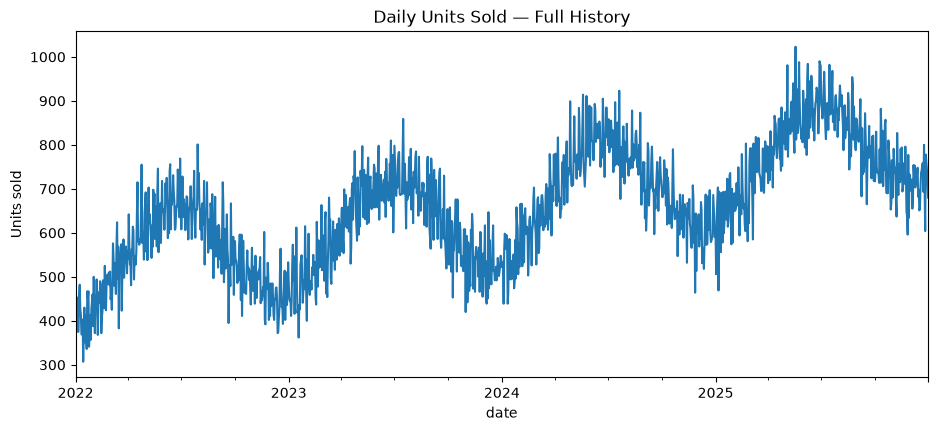

In [23]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)

df["units_sold"].plot(title="Daily Units Sold — Full History")

plt.ylabel("Units sold")

plt.show()

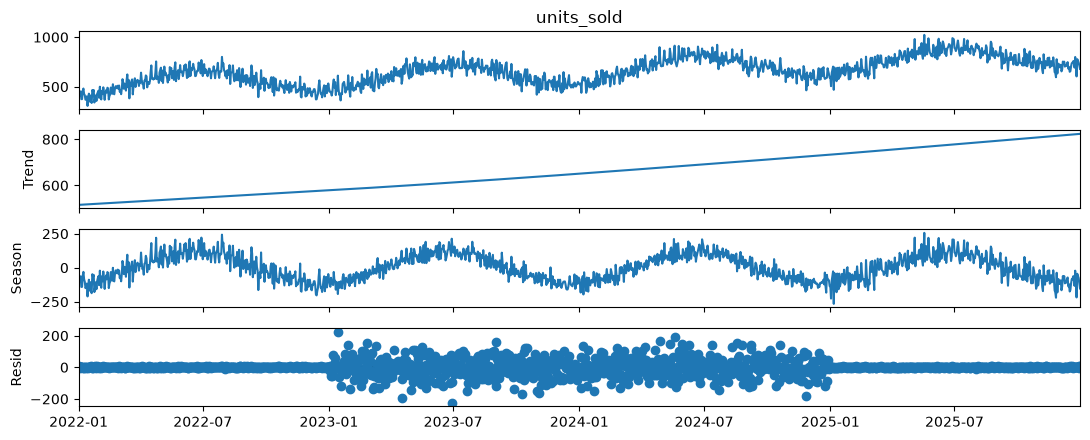

In [24]:
from statsmodels.tsa.seasonal import STL

stl = STL(df["units_sold"], period=365, robust=True)

res = stl.fit()

res.plot()

plt.show()

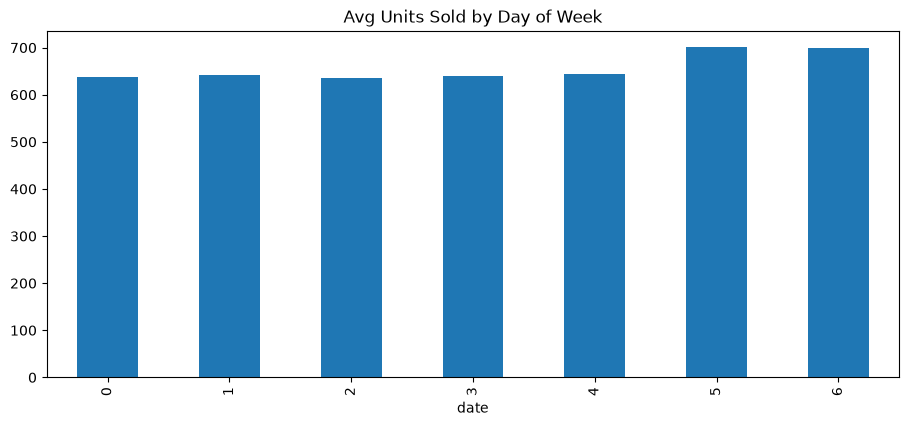

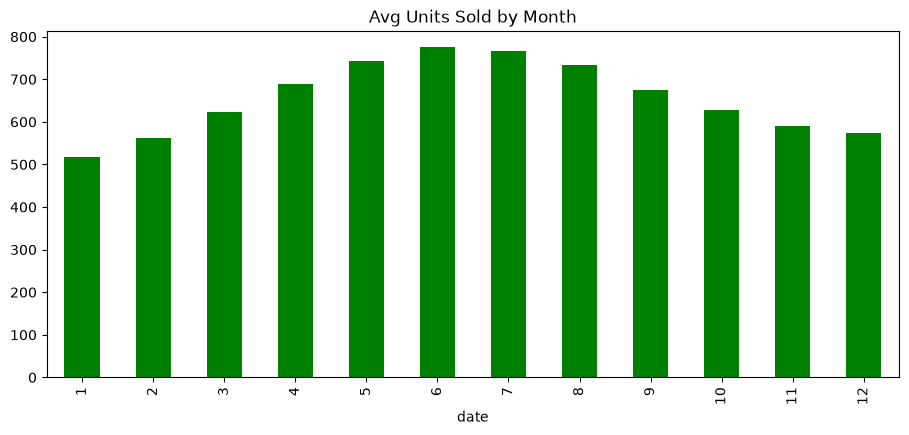

In [25]:
df.groupby(df.index.dayofweek)["units_sold"].mean().plot(
    kind="bar",
    title="Avg Units Sold by Day of Week"
)

plt.show()

df.groupby(df.index.month)["units_sold"].mean().plot(
    kind="bar",
    title="Avg Units Sold by Month",
    color="green"
)

plt.show()

In [26]:
feat = df[["units_sold"]].copy()

feat["t"] = np.arange(len(feat))
feat["dow"] = feat.index.dayofweek
feat["month"] = feat.index.month
feat["is_weekend"] = (feat["dow"] >= 5).astype(int)
feat["doy_sin"] = np.sin(2 * np.pi * feat.index.dayofyear / 365)
feat["doy_cos"] = np.cos(2 * np.pi * feat.index.dayofyear / 365)

feat.head()

,units_sold,t,dow,month,is_weekend,doy_sin,doy_cos
date,,,,,,,
2022-01-01,465.0,0,5,1,1,0.017213,0.999852
2022-01-02,437.0,1,6,1,1,0.034422,0.999407
2022-01-03,413.0,2,0,1,0,0.051620,0.998667
2022-01-04,453.0,3,1,1,0,0.068802,0.997630
2022-01-05,375.0,4,2,1,0,0.085965,0.996298


In [27]:
feat = pd.get_dummies(
    feat,
    columns=["dow", "month"],
    drop_first=True
)

feat.head()

,units_sold,t,is_weekend,doy_sin,doy_cos,dow_1,dow_2,dow_3,dow_4,dow_5,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,465.0,0,1,0.017213,0.999852,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2022-01-02,437.0,1,1,0.034422,0.999407,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2022-01-03,413.0,2,0,0.051620,0.998667,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2022-01-04,453.0,3,0,0.068802,0.997630,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2022-01-05,375.0,4,0,0.085965,0.996298,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [28]:
horizon = 90

train = feat.iloc[:-horizon]
test = feat.iloc[-horizon:]

print(
    "Train:",
    train.index.min().date(),
    "to",
    train.index.max().date(),
    f"({len(train)} days)"
)

print(
    "Test: ",
    test.index.min().date(),
    "to",
    test.index.max().date(),
    f"({len(test)} days)"
)

Train: 2022-01-01 to 2025-10-02 (1371 days)
Test:  2025-10-03 to 2025-12-31 (90 days)


In [29]:
X_train, y_train = train.drop(columns="units_sold"), train["units_sold"]

X_test, y_test = test.drop(columns="units_sold"), test["units_sold"]

print(X_train.shape, X_test.shape)

(1371, 21) (90, 21)


In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0.21, 43.08, 12.78,...,-14.66,-10.75,-14.2 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['t','is_weekend','doy_sin',...,'month_10','month_11','month_12']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,486.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [31]:
lr_pred = lr.predict(X_test)

print(lr_pred[:10])

[746.93954081 802.0133286  800.17146947 733.82465659 738.56865632
 729.09650761 730.88224854 734.6603881  789.78630703 788.00063306]


In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarima_fit = sarima.fit(disp=False)

In [33]:
sarima_forecast = sarima_fit.get_forecast(steps=90)

sarima_pred = sarima_forecast.predicted_mean

sarima_ci = sarima_forecast.conf_int(alpha=0.05)

print(sarima_pred.head())

2025-10-03    755.155344
2025-10-04    812.094235
2025-10-05    812.343820
2025-10-06    748.085063
2025-10-07    754.841477
Freq: D, Name: predicted_mean, dtype: float64


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE": round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "MAPE (%)": round(mape(y_true, y_pred), 2),
        "R2": round(r2_score(y_true, y_pred), 3),
    }

In [35]:
results = pd.DataFrame([
    evaluate("Linear Regression", y_test.values, lr_pred),
    evaluate("SARIMA", y_test.values, sarima_pred.values),
])

results

,Model,MAE,RMSE,MAPE (%),R2
0,Linear Regression,42.94,52.29,5.78,0.076
1,SARIMA,60.20,71.28,8.56,-0.718


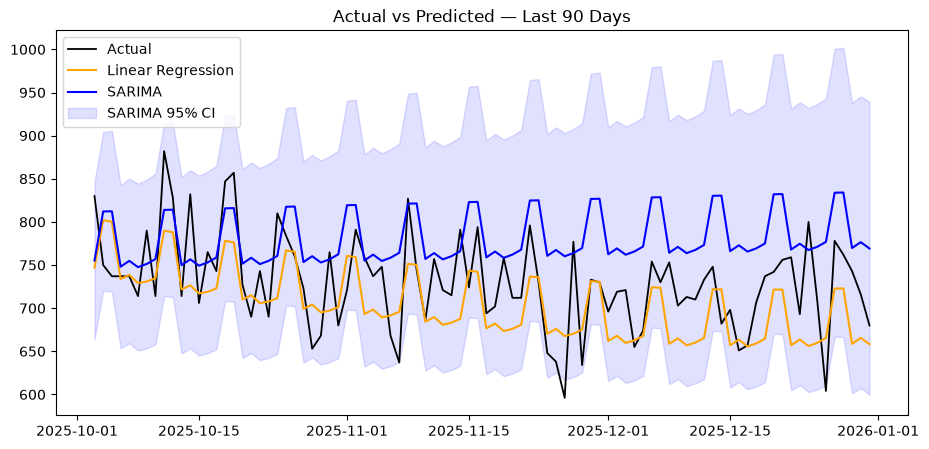

In [36]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    y_test.index,
    y_test.values,
    label="Actual",
    color="black",
    linewidth=1.3
)

ax.plot(
    y_test.index,
    lr_pred,
    label="Linear Regression",
    color="orange"
)

ax.plot(
    y_test.index,
    sarima_pred.values,
    label="SARIMA",
    color="blue"
)

ax.fill_between(
    y_test.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    color="blue",
    alpha=0.12,
    label="SARIMA 95% CI"
)

ax.set_title("Actual vs Predicted — Last 90 Days")

ax.legend()

plt.show()

In [37]:
final_lr = LinearRegression()

final_lr.fit(
    feat.drop(columns="units_sold"),
    feat["units_sold"]
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0.21, 42.42, 12.13,...,-12.9 , -8.13, -6.65]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['t','is_weekend','doy_sin',...,'month_10','month_11','month_12']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,484.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [38]:
future_dates = pd.date_range(
    df.index.max() + pd.Timedelta(days=1),
    periods=90,
    freq="D"
)

future_feat = pd.DataFrame(index=future_dates)

future_feat["t"] = np.arange(len(feat), len(feat) + 90)

future_feat["dow"] = future_feat.index.dayofweek
future_feat["month"] = future_feat.index.month
future_feat["is_weekend"] = (future_feat["dow"] >= 5).astype(int)

future_feat["doy_sin"] = np.sin(
    2 * np.pi * future_feat.index.dayofyear / 365
)

future_feat["doy_cos"] = np.cos(
    2 * np.pi * future_feat.index.dayofyear / 365
)

future_feat = pd.get_dummies(
    future_feat,
    columns=["dow", "month"],
    drop_first=True
)

future_feat = future_feat.reindex(
    columns=feat.drop(columns="units_sold").columns,
    fill_value=0
)

future_feat.head()

,t,is_weekend,doy_sin,doy_cos,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
2026-01-01,1461,0,0.017213,0.999852,False,False,True,False,False,False,...,False,0,0,0,0,0,0,0,0,0
2026-01-02,1462,0,0.034422,0.999407,False,False,False,True,False,False,...,False,0,0,0,0,0,0,0,0,0
2026-01-03,1463,1,0.051620,0.998667,False,False,False,False,True,False,...,False,0,0,0,0,0,0,0,0,0
2026-01-04,1464,1,0.068802,0.997630,False,False,False,False,False,True,...,False,0,0,0,0,0,0,0,0,0
2026-01-05,1465,0,0.085965,0.996298,False,False,False,False,False,False,...,False,0,0,0,0,0,0,0,0,0


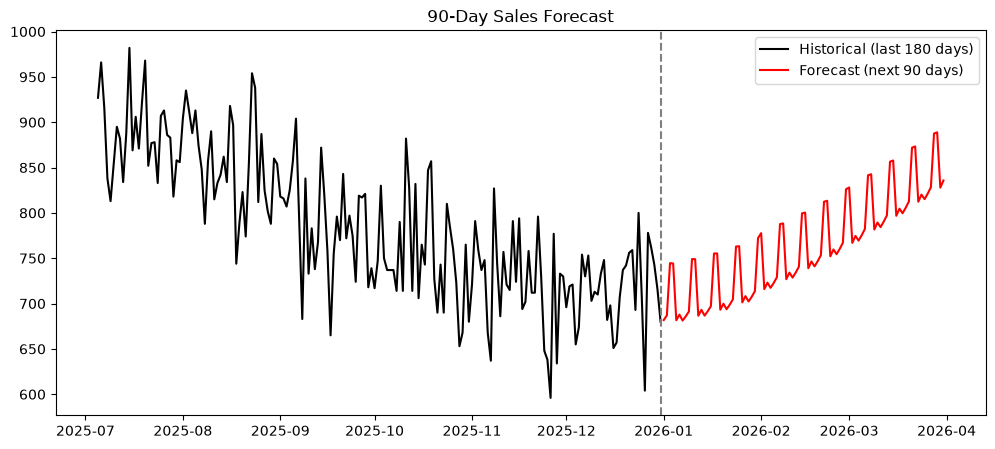

Saved!


In [39]:
future_pred = final_lr.predict(future_feat)

future_df = pd.DataFrame(
    {"forecast": future_pred},
    index=future_dates
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df.index[-180:],
    df["units_sold"].iloc[-180:],
    label="Historical (last 180 days)",
    color="black"
)

ax.plot(
    future_df.index,
    future_df["forecast"],
    label="Forecast (next 90 days)",
    color="red"
)

ax.axvline(
    df.index[-1],
    color="gray",
    linestyle="--"
)

ax.set_title("90-Day Sales Forecast")

ax.legend()

plt.show()

future_df.to_csv("forecast_next_90_days.csv")

print("Saved!")